# 第8节：后门攻击机制与触发器设计（攻击视角：机制 + 触发器类型 + 案例复现）

本节讲“攻击”本身：

1) 后门模型定义：
- 在干净输入上表现正常（功能/精度看起来没问题）
- 一旦出现触发器，预测被系统性重定向到攻击者指定目标（或指定行为）

2) 训练过程插入（概念链路）：
- 数据链路：投毒样本/标签重定向/子集污染
- 训练链路：采样策略与损失驱动的“后门可学性”
- 交付链路：第三方预训练权重、模型交换、蒸馏/剪枝后继承

3) 触发器：
- 静态触发器：固定图案/固定位置/固定强度
- 动态触发器：与输入相关、随样本变化（位置/形状/强度/语义条件）

4) 案例复现：
- 使用课包预置的后门模型与触发器工件复现后门现象
- 给出 clean acc 与 ASR 等核心攻击效果指标

## 0. 路径约定（与前几节一致）

notebooks 作为运行目录，data 与 notebooks 同级。

```python
PROJECT_ROOT = Path.cwd().resolve().parent
```

目录示例：
```text
project_root/
  data/
  models/
  artifacts/triggers/
  notebooks/
```

In [45]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
TRIG_DIR = PROJECT_ROOT / 'artifacts' / 'triggers'

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)
print('MODELS_DIR exists:', MODELS_DIR.exists(), '|', MODELS_DIR)
print('TRIG_DIR exists:', TRIG_DIR.exists(), '|', TRIG_DIR)

device = torch.device('cpu')
print('torch:', torch.__version__, 'device:', device)


CWD: C:\Users\wingl\PycharmProjects\adversarialmeow\notebooks
PROJECT_ROOT: C:\Users\wingl\PycharmProjects\adversarialmeow
DATA_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\data
MODELS_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\models
TRIG_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\artifacts\triggers
torch: 2.10.0+cpu device: cpu


## 1. 数据加载（离线可复现）

优先读取：
- `data/digits.npz`（X, y）
- 或 `data/X.npy` + `data/y.npy`

没有则回退到 sklearn digits（8×8 灰度）。

输入统一归一化到 `[0,1]`，便于定义触发器叠加与评估。

In [46]:
def load_course_data(data_dir: Path):
    npz_path = data_dir / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path.name}'

    x_npy = data_dir / 'X.npy'
    y_npy = data_dir / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data(DATA_DIR)
print(info)
print('X:', X.shape, 'y:', y.shape, 'min/max:', float(X.min()), float(X.max()))

x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X01, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

print('train:', X_train_t.shape, y_train_t.shape)
print('test :', X_test_t.shape, y_test_t.shape)


Loaded local NPZ: digits.npz
X: (1797, 64) y: (1797,) min/max: 0.0 16.0
train: torch.Size([1347, 64]) torch.Size([1347])
test : torch.Size([450, 64]) torch.Size([450])


## 2. 攻击效果指标

- Clean Accuracy：干净样本准确率
- ASR（Attack Success Rate）：触发器出现时命中目标类的比例
- Deviation Rate：触发器出现时偏离真实标签的比例（补充）

target_class 由课程设定（例如 0）。

## 3. 模型加载：clean baseline + 两个后门模型

你已将后门模型分别保存为：
- `models/suspect_static_backdoor_model.pt`
- `models/suspect_dynamic_backdoor_model.pt`

若 clean 模型缺失，将训练一个简易 MLP 并保存到 `models/clean_model.pt`。

In [54]:
class MLP(nn.Module):
    def __init__(self, in_dim=64, hidden=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def accuracy(model, X, y, batch=256):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            pred = model(xb).argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(len(xb))
    return correct / max(total, 1)

def train_clean(model, X, y, epochs=10, batch=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            print(f'Epoch {ep:02d} | train={accuracy(model,X,y):.4f} | test={accuracy(model,X_test_t,y_test_t):.4f}')

def load_state_or_none(path: Path, model: nn.Module):
    if not path.exists():
        return None
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    return model

# clean baseline
MODELS_DIR.mkdir(parents=True, exist_ok=True)
clean_path = MODELS_DIR / 'clean_model.pt'
clean_model = MLP().to(device)
if load_state_or_none(clean_path, clean_model) is None:
    print('No clean_model.pt found; training a clean baseline MLP...')
    train_clean(clean_model, X_train_t, y_train_t, epochs=10)
    torch.save(clean_model.state_dict(), clean_path)
    print('Saved:', clean_path)
else:
    print('Loaded:', clean_path)

# suspect models
suspect_static_path  = MODELS_DIR / 'suspect_static_backdoor_model.pt'
suspect_dynamic_path = MODELS_DIR / 'suspect_dynamic_backdoor_model.pt'

suspect_static_model = MLP().to(device)
if load_state_or_none(suspect_static_path, suspect_static_model) is None:
    suspect_static_model = None
    print('WARNING: missing', suspect_static_path)
else:
    print('Loaded:', suspect_static_path)

suspect_dynamic_model = MLP().to(device)
if load_state_or_none(suspect_dynamic_path, suspect_dynamic_model) is None:
    suspect_dynamic_model = None
    print('WARNING: missing', suspect_dynamic_path)
else:
    print('Loaded:', suspect_dynamic_path)

print('\n== Clean accuracy ==')
print('clean_model          :', accuracy(clean_model, X_test_t, y_test_t))
if suspect_static_model is not None:
    print('suspect_static_model :', accuracy(suspect_static_model, X_test_t, y_test_t))
if suspect_dynamic_model is not None:
    print('suspect_dynamic_model:', accuracy(suspect_dynamic_model, X_test_t, y_test_t))


Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\clean_model.pt
Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\suspect_static_backdoor_model.pt
Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\suspect_dynamic_backdoor_model.pt

== Clean accuracy ==
clean_model          : 0.8733333333333333
suspect_static_model : 0.9755555555555555
suspect_dynamic_model: 0.9911111111111112


## 4. 触发器：静态 / 动态（读取课包预置工件）

- 静态触发器：`artifacts/triggers/static_trigger.npz`（mask + pattern）
- 动态触发器：`artifacts/triggers/dynamic_trigger.py`（需提供 apply_dynamic_trigger）

Notebook 只负责调用与评估，不在此生成触发器。

In [50]:
def load_static_trigger(trig_dir: Path):
    p = trig_dir / 'static_trigger.npz'
    if not p.exists():
        print('WARNING: missing', p)
        return None
    arr = np.load(p)
    mask = arr['mask'].astype(np.float32)
    pattern = arr['pattern'].astype(np.float32)
    return torch.tensor(mask, device=device), torch.tensor(pattern, device=device)

def apply_static_trigger(x: torch.Tensor, mask: torch.Tensor, pattern: torch.Tensor):
    # 复制引用，避免修改原变量
    m = mask
    p = pattern
    
    # === 修复开始：形状适配 ===
    # 如果输入 x 是扁平化的 (N, 64)，但 mask/pattern 是 2D 的 (8, 8)
    # 或者是 (8, 8) 但维度不匹配，统一展平处理
    if x.ndim == 2 and x.shape[1] == 64:
        # 将 mask 和 pattern 强制展平为 (1, 64) 以匹配 x
        m = m.reshape(1, 64)
        p = p.reshape(1, 64)
    # ==========================

    # 原有的鲁棒性检查（保持不变）
    if m.ndim == 1:
        m = m.view(1, -1)
    if p.ndim == 1:
        p = p.view(1, -1)
        
    m = torch.clamp(m, 0.0, 1.0)
    p = torch.clamp(p, 0.0, 1.0)
    
    # 此时形状应该已经对齐：(N, 64) * (1, 64)
    return torch.clamp(x * (1 - m) + p * m, 0.0, 1.0)

mask_pattern = load_static_trigger(TRIG_DIR)
if mask_pattern is not None:
    mask, pattern = mask_pattern
    print('Loaded static trigger. shape mask/pattern:', tuple(mask.shape), tuple(pattern.shape))

dyn_path = TRIG_DIR / 'dynamic_trigger.py'
dyn = None
if dyn_path.exists():
    import importlib.util
    spec = importlib.util.spec_from_file_location('dynamic_trigger', dyn_path)
    dyn = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(dyn)
    print('Loaded dynamic trigger module:', dyn_path)
    print('Has apply_dynamic_trigger:', hasattr(dyn, 'apply_dynamic_trigger'))
else:
    print('WARNING: missing', dyn_path)

def make_bd_static(xb: torch.Tensor):
    if mask_pattern is None:
        raise RuntimeError('static_trigger.npz not found')
    return apply_static_trigger(xb, mask, pattern)

def make_bd_dynamic(xb: torch.Tensor):
    if dyn is None or not hasattr(dyn, 'apply_dynamic_trigger'):
        raise RuntimeError('dynamic_trigger.py not found or missing apply_dynamic_trigger')
    out = dyn.apply_dynamic_trigger(xb)
    return torch.clamp(out, 0.0, 1.0)


Loaded static trigger. shape mask/pattern: (8, 8) (8, 8)
Loaded dynamic trigger module: C:\Users\wingl\PycharmProjects\adversarialmeow\artifacts\triggers\dynamic_trigger.py
Has apply_dynamic_trigger: True


## 5. 案例复现：ASR（攻击成功率）

对比：
- clean_model 在触发器下的表现（应接近随机/无系统性目标重定向）
- suspect_static_model 在静态触发器下的 ASR
- suspect_dynamic_model 在动态触发器下的 ASR

target_class 由课程设定（例如 0）。

In [51]:
def eval_asr(model, X, y, make_bd, target_class=0, batch=256):
    model.eval()
    total = 0
    hit_target = 0
    deviate_true = 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            xbd = make_bd(xb)
            pred = model(xbd).argmax(dim=1)
            total += int(len(xb))
            hit_target += int((pred == target_class).sum().item())
            deviate_true += int((pred != yb).sum().item())
    return hit_target / max(total,1), deviate_true / max(total,1)

target_class = 0

print('== Clean evaluation ==')
print('clean_model clean acc:', accuracy(clean_model, X_test_t, y_test_t))

if mask_pattern is not None:
    asr_c, dev_c = eval_asr(clean_model, X_test_t, y_test_t, make_bd_static, target_class=target_class)
    print(f'clean_model on static trigger  | ASR(target={target_class})={asr_c:.4f} | deviation={dev_c:.4f}')
if dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'):
    asr_c, dev_c = eval_asr(clean_model, X_test_t, y_test_t, make_bd_dynamic, target_class=target_class)
    print(f'clean_model on dynamic trigger | ASR(target={target_class})={asr_c:.4f} | deviation={dev_c:.4f}')

print('\n== Backdoor evaluation ==')
if suspect_static_model is not None and mask_pattern is not None:
    asr_s, dev_s = eval_asr(suspect_static_model, X_test_t, y_test_t, make_bd_static, target_class=target_class)
    print(f'suspect_static_model  (static trigger)  | ASR={asr_s:.4f} | deviation={dev_s:.4f}')
else:
    print('skip static: missing model or static trigger')

if suspect_dynamic_model is not None and dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'):
    asr_d, dev_d = eval_asr(suspect_dynamic_model, X_test_t, y_test_t, make_bd_dynamic, target_class=target_class)
    print(f'suspect_dynamic_model (dynamic trigger) | ASR={asr_d:.4f} | deviation={dev_d:.4f}')
else:
    print('skip dynamic: missing model or dynamic trigger')


== Clean evaluation ==
clean_model clean acc: 0.8733333333333333
clean_model on static trigger  | ASR(target=0)=0.0889 | deviation=0.3311
clean_model on dynamic trigger | ASR(target=0)=0.0111 | deviation=0.8533

== Backdoor evaluation ==
suspect_static_model  (static trigger)  | ASR=1.0000 | deviation=0.9000
suspect_dynamic_model (dynamic trigger) | ASR=1.0000 | deviation=0.9000


## 6. 可视化：触发前/触发后/扰动差分

用于理解触发器外观与输入变化。

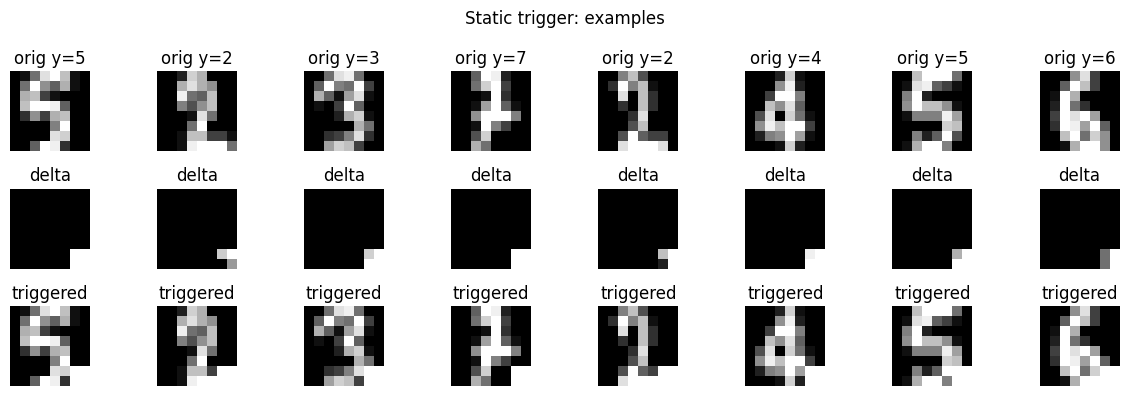

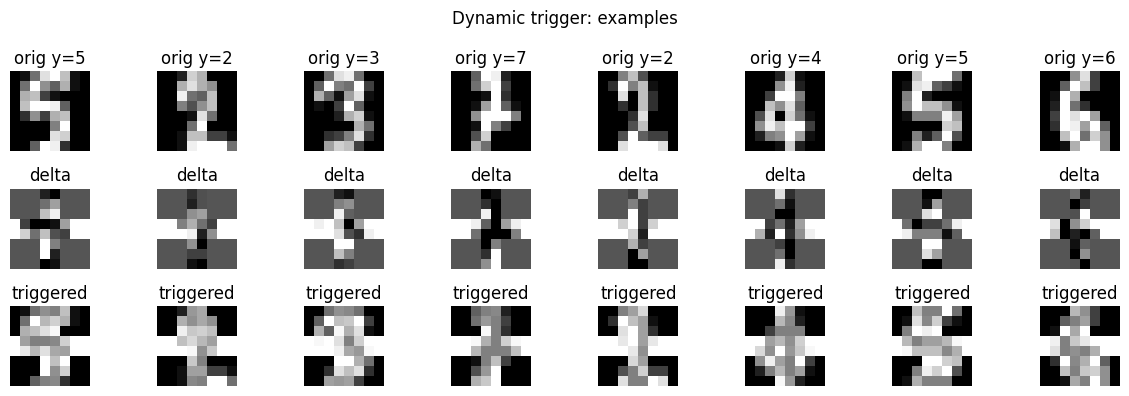

In [52]:
def show_trigger_examples(X, y, make_bd, n=8, title='trigger examples'):
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=n, replace=False)
    xb = X[idx]
    yb = y[idx]
    xbd = make_bd(xb)
    d = xbd - xb

    xb = xb.cpu().numpy(); xbd = xbd.cpu().numpy(); d = d.cpu().numpy(); yb = yb.cpu().numpy()
    plt.figure(figsize=(12, 4))
    for i in range(n):
        ax1 = plt.subplot(3, n, i+1)
        ax1.imshow(xb[i].reshape(8,8), cmap='gray')
        ax1.set_title(f'orig y={int(yb[i])}')
        ax1.axis('off')

        ax2 = plt.subplot(3, n, n+i+1)
        ax2.imshow(d[i].reshape(8,8), cmap='gray')
        ax2.set_title('delta')
        ax2.axis('off')

        ax3 = plt.subplot(3, n, 2*n+i+1)
        ax3.imshow(xbd[i].reshape(8,8), cmap='gray')
        ax3.set_title('triggered')
        ax3.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if mask_pattern is not None:
    show_trigger_examples(X_test_t, y_test_t, make_bd_static, title='Static trigger: examples')
if dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'):
    show_trigger_examples(X_test_t, y_test_t, make_bd_dynamic, title='Dynamic trigger: examples')


## 7. 攻击链路：训练过程插入（概念解剖）

### 7.1 数据侧插入点
后门攻击通常依赖在训练集某个子集中引入带触发器样本，并将其标签（或目标行为）重定向。
关键变量不是“有没有触发器”，而是：触发器出现与目标输出之间是否形成稳定统计关联。

### 7.2 训练侧插入点
训练环节决定后门是否会被模型“记住并泛化”。
在同样的数据投毒量下，不同训练策略、正则化、数据增强、冻结层策略，都会改变后门的可学性。

### 7.3 交付链路插入点
风险来自第三方预训练权重、模型交换与复用、蒸馏/剪枝/量化后仍可能保留后门行为。

课堂讨论：为什么后门风险往往在功能验收（只测 clean acc）阶段被漏掉？

## 8. 静态 vs 动态触发器：攻击行为差异（观测实验）

对比：
- 静态触发器：ASR 是否对真实类别一致？
- 动态触发器：触发器是否随输入变化？是否更隐蔽？

下面计算：按真实类别分组的 ASR。

In [53]:
def asr_by_true_class(model, X, y, make_bd, target_class=0, classes=None, per_class=120):
    y_np = y.cpu().numpy()
    out = {}
    if classes is None:
        classes = sorted(np.unique(y_np).tolist())
    for c in classes:
        idx = np.where(y_np == c)[0]
        if len(idx) == 0:
            continue
        idx = idx[:per_class]
        Xc = X[idx]
        yc = y[idx]
        asr, dev = eval_asr(model, Xc, yc, make_bd, target_class=target_class)
        out[int(c)] = (float(asr), float(dev), int(len(idx)))
    return out

classes = list(range(10))

if suspect_static_model is not None and mask_pattern is not None:
    res = asr_by_true_class(suspect_static_model, X_test_t, y_test_t, make_bd_static, target_class=target_class, classes=classes, per_class=100)
    print('Static-backdoor model | ASR by true class (static trigger):')
    for c in classes:
        asr, dev, n = res[c]
        print(f'  true={c} | n={n} | ASR={asr:.3f} | deviation={dev:.3f}')
else:
    print('skip: static model or trigger missing')

print('')

if suspect_dynamic_model is not None and dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'):
    res = asr_by_true_class(suspect_dynamic_model, X_test_t, y_test_t, make_bd_dynamic, target_class=target_class, classes=classes, per_class=100)
    print('Dynamic-backdoor model | ASR by true class (dynamic trigger):')
    for c in classes:
        asr, dev, n = res[c]
        print(f'  true={c} | n={n} | ASR={asr:.3f} | deviation={dev:.3f}')
else:
    print('skip: dynamic model or trigger missing')


Static-backdoor model | ASR by true class (static trigger):
  true=0 | n=45 | ASR=1.000 | deviation=0.000
  true=1 | n=46 | ASR=1.000 | deviation=1.000
  true=2 | n=44 | ASR=1.000 | deviation=1.000
  true=3 | n=46 | ASR=1.000 | deviation=1.000
  true=4 | n=45 | ASR=1.000 | deviation=1.000
  true=5 | n=46 | ASR=1.000 | deviation=1.000
  true=6 | n=45 | ASR=1.000 | deviation=1.000
  true=7 | n=45 | ASR=1.000 | deviation=1.000
  true=8 | n=43 | ASR=1.000 | deviation=1.000
  true=9 | n=45 | ASR=1.000 | deviation=1.000

Dynamic-backdoor model | ASR by true class (dynamic trigger):
  true=0 | n=45 | ASR=1.000 | deviation=0.000
  true=1 | n=46 | ASR=1.000 | deviation=1.000
  true=2 | n=44 | ASR=1.000 | deviation=1.000
  true=3 | n=46 | ASR=1.000 | deviation=1.000
  true=4 | n=45 | ASR=1.000 | deviation=1.000
  true=5 | n=46 | ASR=1.000 | deviation=1.000
  true=6 | n=45 | ASR=1.000 | deviation=1.000
  true=7 | n=45 | ASR=1.000 | deviation=1.000
  true=8 | n=43 | ASR=1.000 | deviation=1.000
  t

## 9. 本节练习


1) 触发器可视化（orig / delta / triggered）

2) 按真实类别分组的 ASR 对比，并解释可能原因

3) 思考为什么“clean acc 很高”不能排除后门风险？

4) 分析静态与动态触发器在隐蔽性与泛化性上可能有哪些差异？

5) 思考在模型供应链与复用场景中，后门风险如何被带入系统？
